In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pynwb import TimeSeries
from pynwb import NWBHDF5IO
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
import jax

# Load data

In [2]:
import numpy as np
from scipy.io import loadmat

data = loadmat(
    "/stelmo/sam/c3po_datasets/moser_mec_25843_2_openfield.mat"
)  # in the downloadable Vollan archive, this is 27765_2.mat  (potentially can do this with any other data file)
# print(data)

In [3]:
def mat_fields(s):
    """Return field names for a MATLAB struct (np.void or structured ndarray)."""
    if isinstance(s, np.ndarray) and s.dtype.names:
        return s.dtype.names
    if isinstance(s, np.void) and s.dtype.names:
        return s.dtype.names
    raise TypeError("Not a MATLAB struct (np.void/structured ndarray).")

In [193]:
# MATLAB structs come in as nested numpy.void objects
# The 'Dsession' key gives the main struct
Dsession = data["Dsession"]

t = Dsession["t"][0, 0].flatten()  # times
x = Dsession["x"][0, 0].flatten()  # x positions
y = Dsession["y"][0, 0].flatten()  # y positions
speed = Dsession["speed"][0, 0].flatten()  #
thetaphase = Dsession["theta"][0, 0].flatten()  #
units = Dsession["units"][0, 0].flatten()  # unit data (more parsing below)
unit_cluster_id = units["mec"][0]["acorrCluId"][:]
head_direction = Dsession["hd"][0, 0].flatten()  #
# sessions         = Dsession['sessions'][0,0].flatten()   # let's ignore for now i think

In [7]:
mat_fields(units["mec"][0])

is_grid = np.squeeze(units["mec"][0]["isGrid"][:].flatten())
np.unique(is_grid, return_counts=True)
np.where(is_grid)[0].size

650

In [8]:
from spyglass.common.common_interval import Interval

speed_thresh = 0.1

running_intervals = Interval(
    np.where(speed > speed_thresh)[0], from_inds=True
).to_seconds(t)
running_intervals = Interval(running_intervals)

[2025-12-10 14:15:36,027][INFO]: Connecting sambray@lmf-db.cin.ucsf.edu:3306
[2025-12-10 14:15:36,086][INFO]: Connected sambray@lmf-db.cin.ucsf.edu:3306


In [9]:
# units['mec'][0]['spikeTimes'][0][0].shape   # spike times for the 1st unit
# units['mec'][0]['spikeTimes'][1][0].shape   # spike times for the 2nd unit
# units['mec'][0]['spikeTimes'][2][0].shape   # spike times for the 3rd unit

# gather spike data (list of numpy arrays)
spikes = []
for uu in range(len(units["mec"][0]["spikeTimes"])):
    spikes.append(units["mec"][0]["spikeTimes"][uu][0].flatten())
print(len(spikes), "units")

1522 units


In [ ]:
from jax.nn import one_hot

cluster_id = None

spike_times = []
spike_ids = []
id_ = 0
for i, s in enumerate(spikes):
    if cluster_id is not None and unit_cluster_id[i] != cluster_id:
        continue
    spike_times.extend(s)
    spike_ids.extend([id_] * len(s))
    id_ += 1
print(f"{id_} units")
spike_times = np.array(spike_times)
spike_ids = np.array(spike_ids)
ind = np.argsort(spike_times)
spike_times = spike_times[ind]
spike_ids = spike_ids[ind]

delta_t = np.diff(spike_times) * 1000  # convert to ms
waveforms = spike_ids[1:]

ind_pos = np.where(delta_t > 0)[0]
spike_ids = spike_ids[ind_pos]
spike_times = spike_times[ind_pos]
delta_t = delta_t[ind_pos]
waveforms = waveforms[ind_pos]

delta_t.shape, waveforms.shape

1522 units


((2723125,), (2723125,))

In [ ]:
# seg_length = 1000
# n_overlap = 30
seg_length = 10000
n_overlap = 3000
min_run_frac = 0

n_segments = (len(delta_t) - seg_length) // n_overlap + 1

valid_times = np.zeros(spike_times.size, dtype=bool)
ind_valid = running_intervals.contains(spike_times, as_indices=True)
valid_times[ind_valid] = True

delta_t_train = []
waveforms_train = []
for i in range(n_segments):
    start = i * n_overlap
    end = start + seg_length
    if np.mean(valid_times[start:end]) < min_run_frac:
        continue
    if np.max(delta_t[start:end] > 100):
        continue
    delta_t_train.append(delta_t[start : end - 1])
    waveforms_train.append(waveforms[start : end - 1])
delta_t_train = np.array(delta_t_train, dtype=np.float32)
waveforms_train = np.array(waveforms_train, dtype=np.int16)[:, :, np.newaxis]
print(delta_t_train.shape, waveforms_train.shape)
# delta_t_train *= 1000  # convert to ms

(347, 9999) (347, 9999, 1)


In [ ]:
np.min(delta_t_train), np.min(delta_t)

(1.6261765e-09, 3.637978807091713e-11)

# Make model

In [75]:
import os

os.chdir("/home/sambray/Documents/c3po")

from src.c3po.model.model import C3PO

### Wavenet Model

In [ ]:
latent_dim = 16
context_dim = 16

encoder_args = {
    "encoder_model": "sorted_spikes",
    "n_units": np.max(spike_ids) + 1,
    "gauss_noise_std": 0,
    "input_format": "indices",
}

encoder_args = dict(
    encoder_model="sorted_spikes",
    n_units=np.max(waveforms),
    gauss_noise_std=0,
    input_format="indices",
)

context_args = {
    "context_model": "wavenet",
    "layer_dilations": [1, 2, 4, 8, 1, 2, 4, 8],
    "layer_kernel_size": [8, 8, 16, 16, 8, 8, 16, 16],
    "expanded_dim": 64,
    "smoothing": 20,
    "smoothing_decay": 0.9,
    "categorical": False,
}

rate_args = {"rate_model": "sharedSpace"}

distribution = "poisson"
predicted_sequence_length = 1


model = C3PO(
    encoder_args,
    context_args,
    rate_args,
    distribution,
    latent_dim,
    context_dim,
    n_neg_samples,
    predicted_sequence_length,
    return_embeddings_in_call=True,
)

params = model.init(
    jax.random.PRNGKey(1),
    waveforms_train[
        :2,
        :300,
    ],
    delta_t_train[:2, :300],
    rand_key,
)
init_params = params.copy()
run_model = jax.jit(model.apply)

In [ ]:
z, c = model.apply(
    params, waveforms_train[:2, :300], delta_t_train[:2, :300], rand_key
)[0]

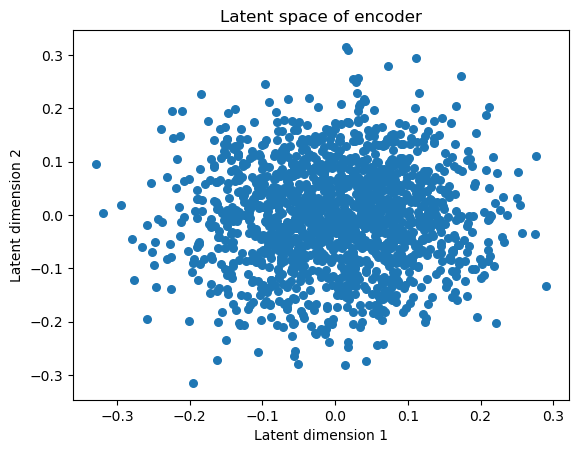

In [165]:
initial_embed_matrix = params["params"]["embedding"]["encoder"]["encoder_matrix"].copy()
plt.scatter(initial_embed_matrix[:, 0], initial_embed_matrix[:, 1], s=30)
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Latent space of encoder")
plt.show()

In [33]:
waveforms_train.shape

(347, 9999, 1522)

## Train Model

In [ ]:
from src.c3po.model.model import train_model, update_n_neg

params, tracked_loss = train_model(
    model,
    params,
    waveforms_train,
    delta_t_train,
    learning_rate=3e-4,
    n_epochs=1000,
    initial_batch_size=128,
    buffer_size=10,
    min_batch_size=16,
    max_n_neg=256,
    initial_n_neg=8,
)

Epoch 60:  74%|███████▍  | 256/347 [00:02<00:00, 113.30samples/s, batch_size=128, loss=5.45, n_neg=256]


Stalled training, decreasing batch size to 64 and n_neg to 32


Epoch 100:  92%|█████████▏| 320/347 [00:03<00:00, 82.03samples/s, batch_size=64, loss=5.36, n_neg=256]


Stalled training, decreasing batch size to 32 and n_neg to 32


Epoch 140:  92%|█████████▏| 320/347 [00:03<00:00, 85.48samples/s, batch_size=32, loss=5.26, n_neg=256]


Stalled training, decreasing batch size to 16 and n_neg to 32


Epoch 180:  97%|█████████▋| 336/347 [00:05<00:00, 59.56samples/s, batch_size=16, loss=5.14, n_neg=256]

Stalled training, no further adjustments possible.


# Analyze

In [178]:
from src.c3po.analysis.analysis import C3poAnalysis

analysis_encoder_args = {**encoder_args}
# analysis_encoder_args.update({"gauss_noise_std": 0})
model_args = dict(
    encoder_args=analysis_encoder_args,
    context_args=context_args,
    rate_args=rate_args,
    distribution=distribution,
    latent_dim=latent_dim,
    context_dim=context_dim,
    n_neg_samples=n_neg_samples,
    predicted_sequence_length=predicted_sequence_length,
    sample_params=None,
)
analysis = C3poAnalysis(model=model, model_args=model_args, params=params)

In [203]:
model_name = "mec_wavenet_25843_all_cells"


analysis.save_embedding(f"/stelmo/sam/c3po_results/{model_name}_embedding.npz")
from flax import serialization

from src.c3po.tables.dev_tables import C3POStorage

C3POStorage()
insert_key = {
    "model_name": model_name,
    "encoder_args": encoder_args,
    "context_args": context_args,
    "rate_args": rate_args,
    "latent_dim": latent_dim,
    "context_dim": context_dim,
    "learned_params": serialization.to_bytes(params),
    "input_shape": np.array(waveforms_train.shape[-1]),
}

C3POStorage().insert1(insert_key)

In [195]:
# embed data and make pca
analysis.embed_data(
    waveforms[None, :, None],
    delta_t[None, :],
    delta_t_units="ms",
    first_mark_time=spike_times[0],
)
t_interp = np.arange(np.min(spike_times), np.max(spike_times), 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca()  # no_gap_intervals)  # running_intervals)
analysis.embed_context_pca()

 99%|█████████▉| 2700000/2723125 [00:01<00:00, 2437403.61it/s]


In [192]:
spike_times[0]
t[0]

10624.39

In [157]:
analysis.__dict__.keys()

dict_keys(['model', 'model_args', 'params', 'z', 'c', 't', 't_interp', 'c_interp', 'c_pca', 'c_pca_interp', 'latent_dim', 'context_dim', 'decoder_model', 'decode_pca', 'pca', 'pca_intervals'])

In [154]:
np.nanmax(analysis.c)

0.5704700946807861

In [180]:
max_delay = 100
dt = np.diff(analysis.t)
ind_smooth = np.where(dt < max_delay)[0]
no_gap_intervals = Interval(
    Interval(ind_smooth, from_inds=True).to_seconds(analysis.t[1:])
)

[5.12783570e+01 1.81073155e+01 1.34696077e+01 1.00630146e+01
 4.80502902e+00 9.16644582e-01 7.18143799e-01 1.59265383e-01
 1.48234646e-01 1.24349130e-01 6.62032039e-02 4.54237497e-02
 3.18303777e-02 3.05275398e-02 2.15498194e-02 1.45039663e-02]


Text(0, 0.5, 'context variables')

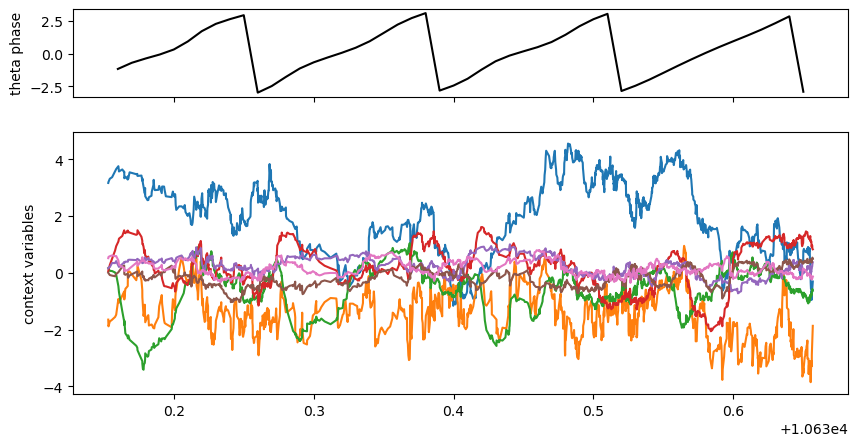

In [196]:
fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[1, 3], figsize=(10, 5))
ind = slice(11000, 12300)
# ind = slice(12000,12300)
# ind = slice(150000, 160000)

ax[1].plot(analysis.t[ind], analysis.c_pca[ind, 3:10])
plot_interval = Interval(np.array([[analysis.t[ind][0], analysis.t[ind][-1]]]))
behavior_inds = plot_interval.contains(t, as_indices=True)
ax[0].plot(t[behavior_inds], thetaphase[behavior_inds], c="k")
print(analysis.pca.explained_variance_ratio_ * 100)
ax[0].set_ylabel("theta phase")
ax[1].set_ylabel("context variables")

Text(0.5, 0, 'Theta phase (rad)')

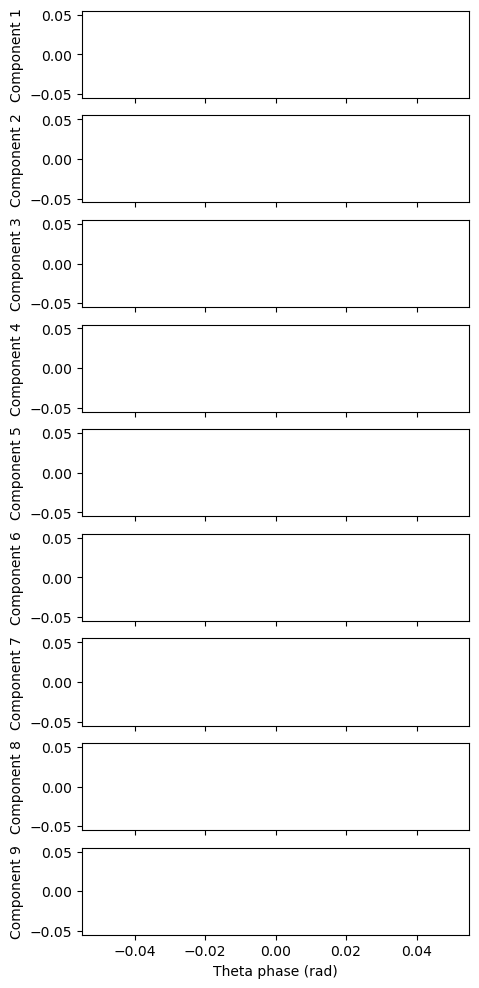

In [125]:
context_binned, bins = analysis.bin_context_by_feature(
    thetaphase, t, bins=np.linspace(-np.pi, np.pi, 30), pca=True
)

fig, ax = plt.subplots(nrows=9, sharex=True, figsize=(5, 12))
for dat, loc in zip(context_binned, bins):
    for i, a in enumerate(ax):
        color = "cornflowerblue"
        a.scatter(loc, np.median(dat[:, i]), c=color)
        a.vlines(
            loc, np.percentile(dat[:, i], 25), np.percentile(dat[:, i], 75), color=color
        )
for i, a in enumerate(ax):
    a.set_ylabel(f"Component {i+1}")
plt.xlabel("Theta phase (rad)")

In [185]:
context_binned

[array([[-1.7511789 ,  6.05664475, -2.21921369, ..., -0.09791759,
          0.17810451, -0.01048146],
        [-2.54016215,  6.44999606, -2.38552841, ..., -0.03588023,
          0.23272074, -0.03745997],
        [-3.46778768,  6.4500615 , -2.39352207, ...,  0.01888497,
          0.22849891, -0.02315965],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]),
 array([[10.92305936, -1.32894931, -5.81163654, ...,  0.04846955,
          0.21329756,  0.07826675],
        [10.88025104, -1.50552014, -5.47050713, ...,  0.08279831,
          0.22193367,  0.0492979 ],
        [10.06983088, -1.01121243, -5.56283912, ...,  0.09098886,
          0.22897438,  0.06859967],
        ...,
        [        nan,         nan,         nan, ...,  

In [ ]:
t.min()

10624.39

-3.1415224075317383
-2.9248633877984407
-2.7082043680651435
-2.491545348331846
-2.274886328598549
-2.058227308865251
-1.8415682891319538
-1.6249092693986564
-1.408250249665359
-1.1915912299320617
-0.9749322101987641
-0.7582731904654669
-0.5416141707321693
-0.3249551509988722
-0.10829613126557458
0.10836288846772257
0.32502190820102017
0.5416809279343178
0.7583399476676149
0.9749989674009125
1.1916579871342101
1.4083170068675068
1.6249760266008044
1.841635046334102
2.0582940660673996
2.274953085800697
2.491612105533994
2.7082711252672915
2.924930145000589


(-3.0, 3.0)

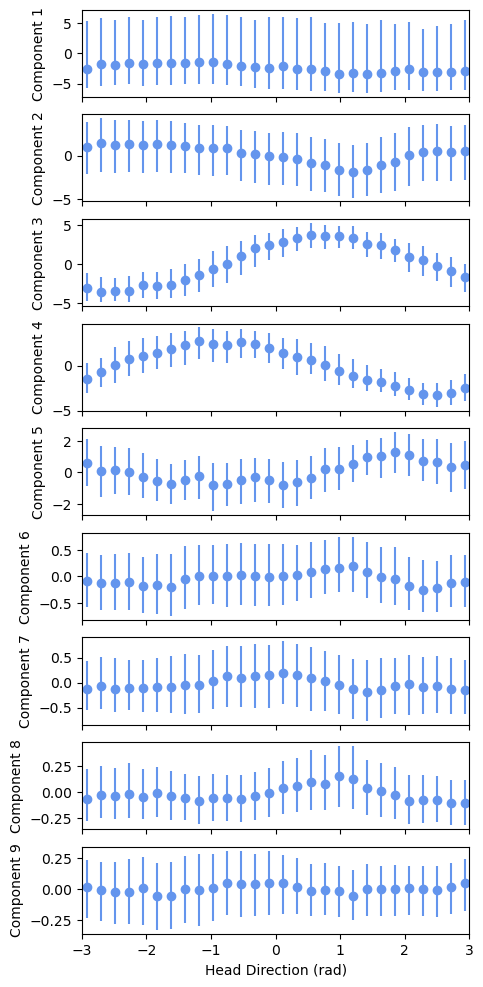

In [ ]:
context_binned, bins = analysis.bin_context_by_feature(head_direction, t, pca=True)

fig, ax = plt.subplots(nrows=9, sharex=True, figsize=(5, 12))
for dat, loc in zip(context_binned, bins):
    print(loc)
    for i, a in enumerate(ax):
        color = "cornflowerblue"
        a.scatter(loc, np.nanmedian(dat[:, i]), c=color)
        a.vlines(
            loc,
            np.nanpercentile(dat[:, i], 25),
            np.nanpercentile(dat[:, i], 75),
            color=color,
        )
for i, a in enumerate(ax):
    a.set_ylabel(f"Component {i+1}")
plt.xlabel("Head Direction (rad)")
plt.xlim(-3, 3)

ValueError: autodetected range of [nan, nan] is not finite

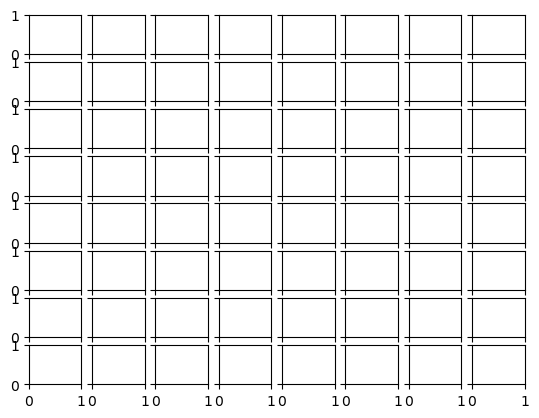

In [198]:
c_pca = analysis.c_pca_interp
# ind = running_intervals.contains(analysis.t, as_indices=True)
ind = no_gap_intervals.contains(analysis.t_interp, as_indices=True)
# ind = np.arange(c_pca.shape[0])

n_plot = 8
fig, ax = plt.subplots(nrows=n_plot, ncols=n_plot, sharex="col", sharey="row")

for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        pc_ind = (i, j)
        H, bx, by = np.histogram2d(
            c_pca[ind, pc_ind[0]], c_pca[ind, pc_ind[1]], bins=100
        )
        H += 1e-3
        H = H / H.sum()
        H = np.log10(H)

        ax[i, j].imshow(H, clim=(-4, -3))
# plt.colorbar()

# plt.scatter(c_pca_interp[ind, 4], c_pca_interp[ind, 2], s=1, alpha=0.01)
# plt.scatter(c_pca_interp[ind, 2], c_pca_interp[ind, 3], s=1, alpha=0.1)

Text(0.5, 0, 'PC 4')

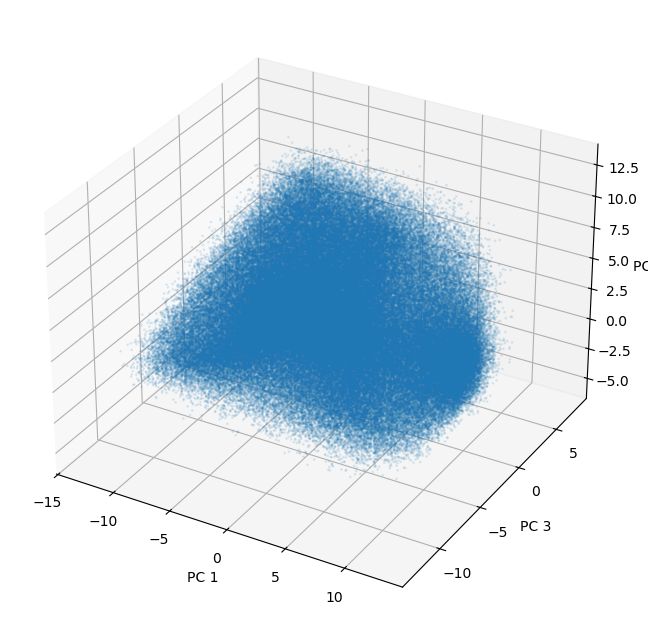

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

plot_dims = (0, 1, 2)
plot_dims = (1, 2, 0)
plot_dims = (0, 2, 3)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sub = 10
c_pca_interp = analysis.c_pca_interp
ind = running_intervals.contains(analysis.t_interp, as_indices=True)[::sub]
ax.scatter(
    c_pca_interp[ind, plot_dims[0]],
    c_pca_interp[ind, plot_dims[1]],
    c_pca_interp[ind, plot_dims[2]],
    s=1,
    alpha=0.1,
)
ax.set_xlabel(f"PC {plot_dims[0] + 1}")
ax.set_ylabel(f"PC {plot_dims[1] + 1}")
ax.set_zlabel(f"PC {plot_dims[2] + 1}")

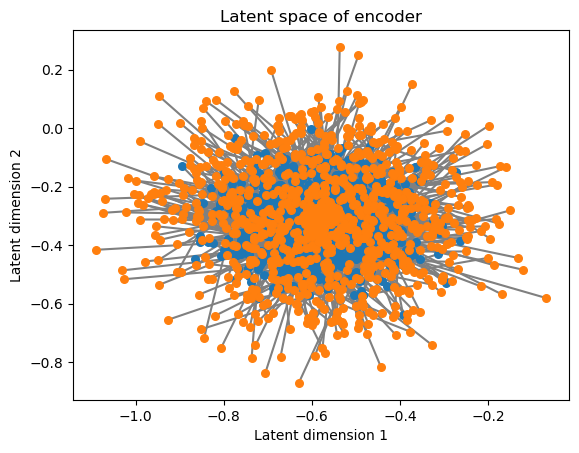

In [ ]:
embed_matrix = params["params"]["embedding"]["encoder"]["encoder_matrix"].copy()

plot_embed_matrix = analysis.pca.transform(embed_matrix)
plot_initial_embed_matrix = analysis.pca.transform(initial_embed_matrix)

plt.scatter(plot_initial_embed_matrix[:, 0], plot_initial_embed_matrix[:, 1], s=30)
plt.scatter(plot_embed_matrix[:, 0], plot_embed_matrix[:, 1], s=30)
for i in range(embed_matrix[:, 0].size):
    plt.plot(
        [plot_embed_matrix[i, 0], plot_initial_embed_matrix[i, 0]],
        [plot_embed_matrix[i, 1], plot_initial_embed_matrix[i, 1]],
        c="grey",
        zorder=-3,
    )

plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("Latent space of encoder")
plt.show()

In [ ]:
bins = np.linspace(np.min(x), np.max(x), 30)
c_binned, bins_x, bins_y = analysis.bin_context_by_feature_2d(
    x, t, y, t, pca=True, bins_1=bins, bins_2=bins
)
h = np.zeros(
    (bins_x.size, bins_y.size, context_dim),
)

for i in range(h.shape[0]):
    for j in range(h.shape[1]):
        if len(c_binned[i][j]) == 0:
            h[i, j] = np.nan
        h[i, j] = np.mean(c_binned[i][j], axis=0)

/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sambray/mambaforge-pypy3/envs/spyglass2025/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


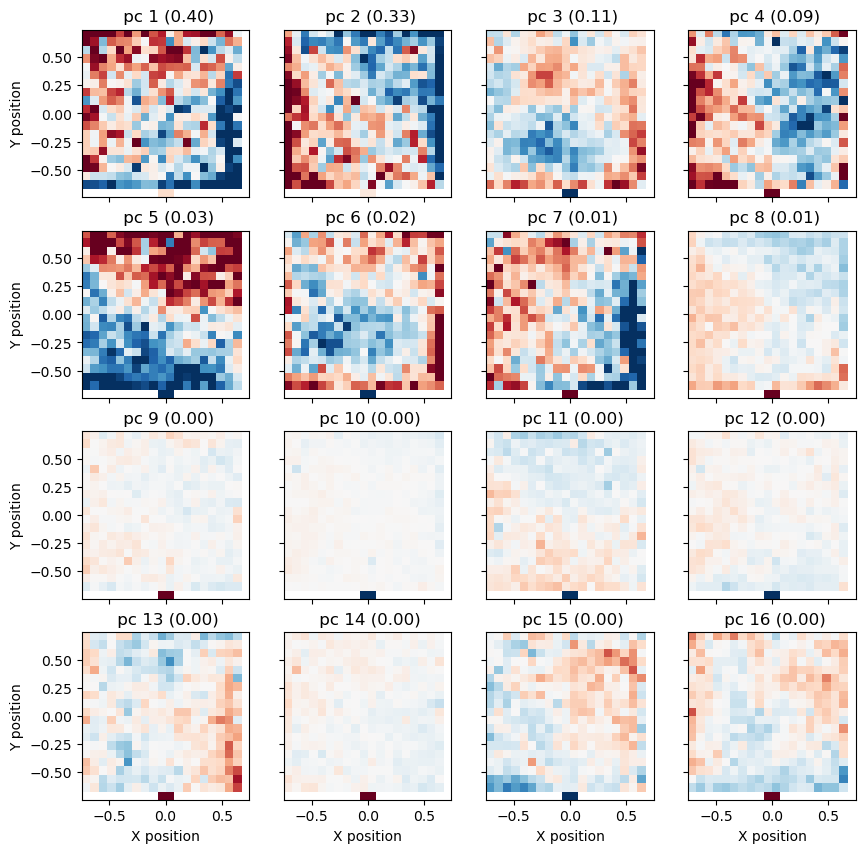

In [ ]:
fig, ax = plt.subplots(
    nrows=min(4, latent_dim),
    ncols=4,
    figsize=(10, 10),
    sharex=True,
    sharey=True,
)
for i, a in enumerate(ax.ravel()):
    if i >= context_dim:
        break
    c_rng = np.nanmax(np.abs(h[:, :, i])) * 0.5
    a.imshow(
        h[:, :, i].T,
        aspect=1,
        origin="lower",
        extent=(bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]),
        cmap="RdBu",
        clim=(-c_rng, c_rng),
    )
    # a.set_title(f"Latent dimension {i+1}")
    # a.set_xlabel("X position (cm)")
    a.set_title(f" pc {i+1} ({analysis.pca.explained_variance_ratio_[i]:.2f})")

for a in ax[:, 0]:
    a.set_ylabel("Y position")


for a in ax[-1, :]:
    a.set_xlabel("X position")

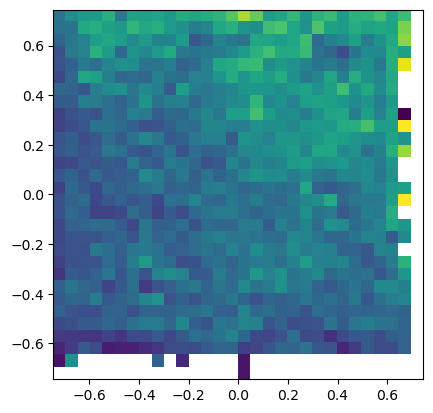

In [ ]:
i = np.where(is_grid)[0][10]

embed_matrix = params["params"]["embedding"]["encoder"]["encoder_matrix"].copy()

z_i = embed_matrix[i]


rates = (h * z_i[None, None, :]).sum(axis=-1)
rates = np.exp(rates)
rates.shape, h.shape
plt.imshow(
    rates.T,
    aspect=1,
    origin="lower",
    extent=(bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]),
)

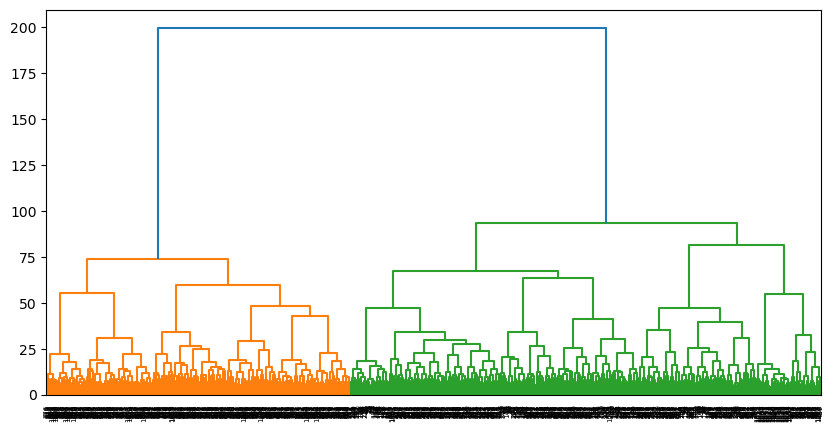

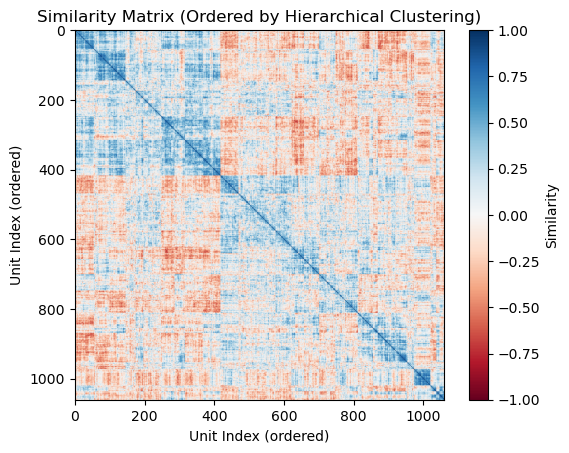

In [ ]:
embed_matrix = params["params"]["embedding"]["encoder"]["encoder_matrix"]

# embed_matrix = params["params"]["rate_prediction"]["W_0"]
# embed_matrix = analysis.pca.transform(embed_matrix)

embed_matrix = embed_matrix / np.linalg.norm(embed_matrix, axis=1, keepdims=True)

sim = embed_matrix @ embed_matrix.T

# plt.imshow(sim, cmap="RdBu", vmin=-1, vmax=1)
# plt.colorbar()

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import leaves_list
from sklearn.cluster import SpectralClustering

# Perform hierarchical clustering on the similarity matrix
linked = linkage(sim, method="ward")
order = leaves_list(linked)

# Plot dendrogram
# plt.figure(figsize=(10, 5))
fig, ax = plt.subplots(
    nrows=1,
    height_ratios=[
        1,
    ],
    figsize=(10, 5),
    sharex=True,
)
dendrogram(linked, ax=ax)
# ax[0].set_title("Hierarchical Clustering Dendrogram")
# ax[0].set_xlabel("Unit Index")
# ax[0].set_ylabel("Distance")

# plt.figure(figsize=(8, 8))
# order = np.squeeze(np.argsort(np.squeeze(unit_cluster_id)))
c_rng = 1
fig = plt.figure()
plt.imshow(sim[order][:, order], aspect=1, cmap="RdBu", clim=(-c_rng, c_rng))
plt.title("Similarity Matrix (Ordered by Hierarchical Clustering)")
plt.xlabel("Unit Index (ordered)")
plt.ylabel("Unit Index (ordered)")
plt.colorbar(label="Similarity")
plt.show()

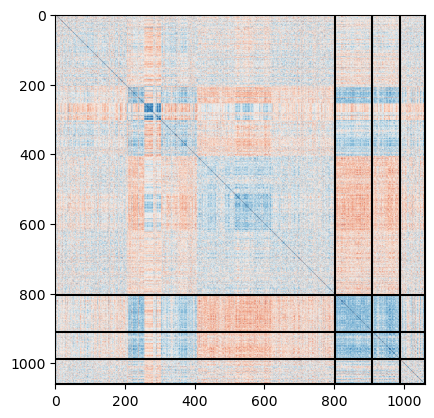

In [ ]:
order = np.squeeze(np.argsort(np.squeeze(unit_cluster_id)))
c_rng = 1
fig = plt.figure()
plt.imshow((sim)[order][:, order], aspect=1, cmap="RdBu", clim=(-c_rng, c_rng))

ax = plt.gca()
clusters, counts = np.unique(unit_cluster_id, return_counts=True)
for i in np.cumsum(counts)[:]:
    ax.axhline(i - 0.5, c="k")
    ax.axvline(i - 0.5, c="k")

In [ ]:
unit_cluster_id[order]
clusters, counts

(array([array([[0]], dtype=uint8), array([[1]], dtype=uint8),
        array([[2]], dtype=uint8), array([[3]], dtype=uint8)], dtype=object),
 array([804, 106,  79,  72]))

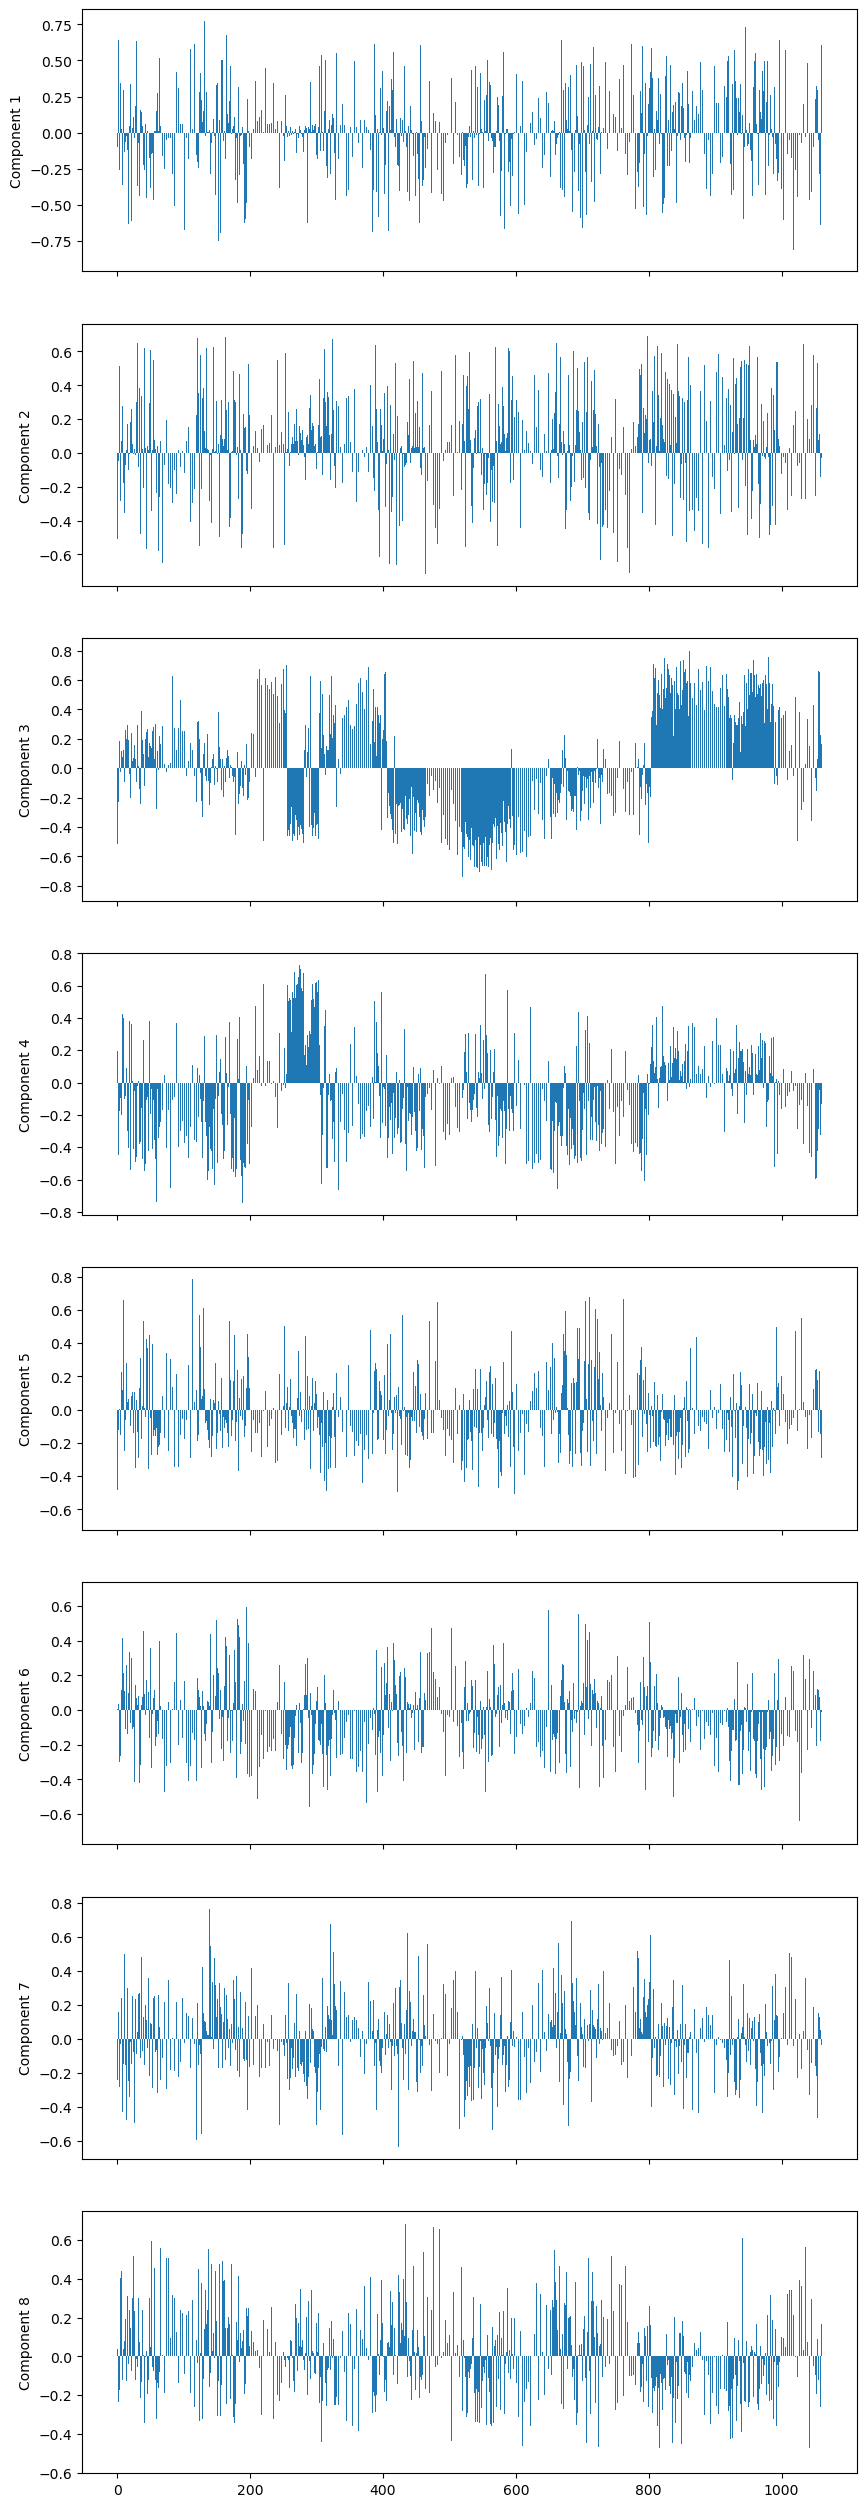

In [ ]:
pca_components = analysis.pca.components_

fig, ax = plt.subplots(
    nrows=min(pca_components.shape[0], 8),
    figsize=(10, 2 * pca_components.shape[0]),
    sharex=True,
)
for i in range(ax.size):
    unit_weights = embed_matrix @ pca_components[i]
    ax[i].bar(
        np.arange(unit_weights.shape[0]),
        unit_weights[order],
    )
    ax[i].set_ylabel(f"Component {i+1}")

In [ ]:
pca_components.shape

(16, 16)